# **Assessing Feature Importance with Random Forests**

Random forests provide a powerful method to measure **feature importance** by calculating the averaged impurity decrease computed across all decision trees in the ensemble. This approach is highly practical because it does not assume the data is linearly separable, and scikit-learn automatically collects and normalizes these values so they sum up to 1.0.

### **1. Extracting Feature Importance**

After fitting a `RandomForestClassifier` in scikit-learn, the relative importance of each feature in the dataset is collected automatically. You can access these rankings directly via the model's `feature_importances_` attribute.

In [ ]:
import pandas as pd

df_wine = pd.read_csv('https://archive.ics.uci.edu/'
                       'ml/machine-learning-databases/'
                       'wine/wine.data', header=None)

df_wine.columns = ['Class label', 'Alcohol',
                    'Malic acid', 'Ash',
                    'Alcalinity of ash', 'Magnesium',
                    'Total phenols', 'Flavanoids',
                    'Nonflavanoid phenols',
                    'Proanthocyanins',
                    'Color intensity', 'Hue',
                    'OD280/OD315 of diluted wines',
                    'Proline']

feat_labels = df_wine.columns[1:]

In [ ]:
from sklearn.model_selection import train_test_split

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=0,
                                                    stratify=y)

 1) Proline                        0.185453
 2) Flavanoids                     0.174751
 3) Color intensity                0.143920
 4) OD280/OD315 of diluted wines   0.136162
 5) Alcohol                        0.118529
 6) Hue                            0.058739
 7) Total phenols                  0.050872
 8) Magnesium                      0.031357
 9) Malic acid                     0.025648
10) Proanthocyanins                0.025570
11) Alcalinity of ash              0.022366
12) Nonflavanoid phenols           0.013354
13) Ash                            0.013279


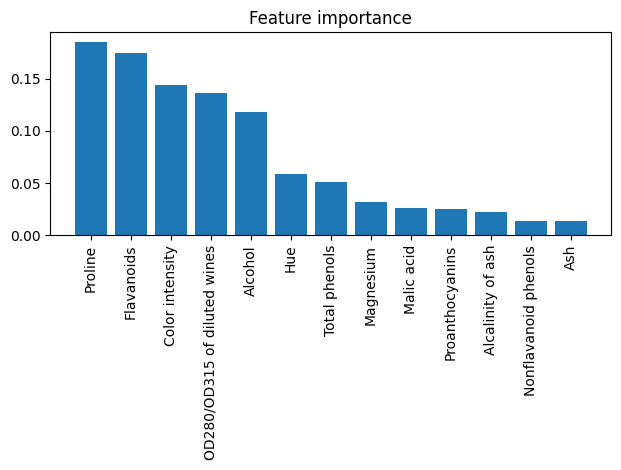

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=500, random_state=1)
forest.fit(X_train, y_train)

# Extract importance values and sort the indices in descending order
importances = forest.feature_importances_
indices = np.argsort(importances)[::-1]

# Print the ranked features
for f in range(X_train.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30, feat_labels[indices[f]], importances[indices[f]]))

# Visualize the feature importances using matplotlib
plt.title('Feature importance')
plt.bar(range(X_train.shape[1]), importances[indices], align='center')
plt.xticks(range(X_train.shape[1]), feat_labels[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

### **2. Feature Selection with SelectFromModel**

Scikit-learn provides the SelectFromModel object to extract specific features based on a user-specified threshold after model fitting. This is highly useful as an intermediate feature selection step within a scikit-learn Pipeline.

Dimensionality Reduction: By defining a threshold (e.g., 0.1), you can effortlessly reduce your dataset to only the most discriminative features.

The Interpretability Gotcha: If two or more features are highly correlated, the random forest might rank one highly while the other is ranked significantly lower, as the shared information is already captured. This does not impact predictive performance, but it is crucial to remember if your primary goal is strictly interpreting feature importance.